In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Make results reproducible
np.random.seed(42)

## 1. Create a Dataset

We will create a synthetic nonlinear regression dataset.

The underlying relationship is:

\[
y = 3x + 10\sin(x) + noise
\]

The noise makes the problem realistic and gives the Decision Tree an opportunity to overfit.

In [2]:
# Generate feature values
X_values = np.sort(np.random.uniform(0, 20, 300))

# Generate nonlinear target with noise
y_values = (
    3 * X_values
    + 10 * np.sin(X_values)
    + np.random.normal(0, 4, 300)
)

# Create DataFrame
df = pd.DataFrame({
    "X": X_values,
    "y": y_values
})

df.head()

,X,y
0,0.101232,1.496571
1,0.110442,-1.172895
2,0.139043,10.378854
3,0.183941,4.916555
4,0.309132,-4.130851


In [3]:
# Basic information about the dataset

print("Shape:", df.shape)
print("\nSummary statistics:")
display(df.describe())

Shape: (300, 2)

Summary statistics:


,X,y
count,300.000000,300.000000
mean,9.904092,29.539571
std,5.886811,17.586186
min,0.101232,-4.130851
25%,4.781616,13.589247
50%,10.234355,28.751873
75%,15.137192,45.572167
max,19.801077,69.526853


## 2. Visualize the Dataset

The scatter plot helps us understand the relationship between the input feature `X` and target `y`.

The relationship is nonlinear and contains noise.

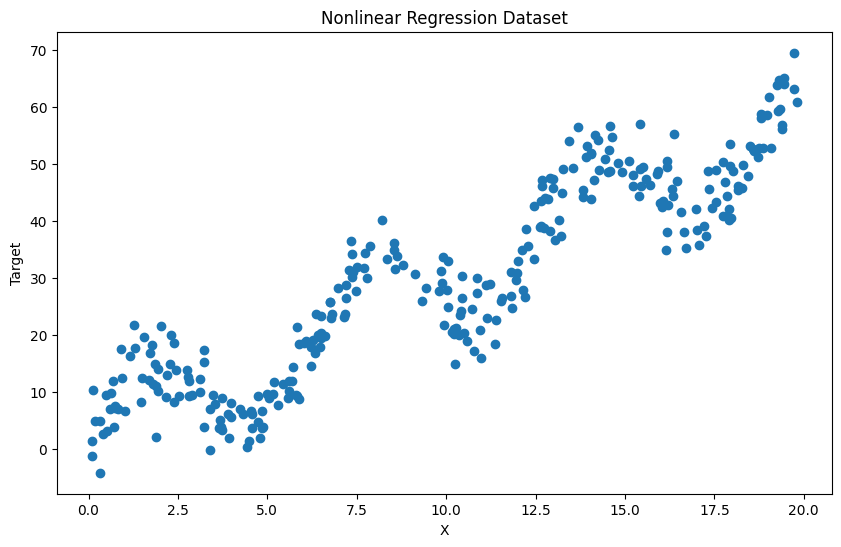

In [4]:
plt.figure(figsize=(10, 6))

plt.scatter(df["X"], df["y"])

plt.xlabel("X")
plt.ylabel("Target")
plt.title("Nonlinear Regression Dataset")

plt.show()

## 3. Train-Test Split

We keep 70% of the observations for training and 30% for testing.

- Training data: used to learn the tree
- Testing data: used to evaluate generalization

In [5]:
X = df[["X"]]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 210
Testing samples : 90


# Part A — Intentionally Create an Overfitted Decision Tree

## 4. Fully Grown Decision Tree

We intentionally do not restrict the tree.

This is useful for demonstrating what happens when a Decision Tree is allowed to become too complex.

In [6]:
# Create an unrestricted Decision Tree
dt = DecisionTreeRegressor(
    random_state=42
)

# Train the model
dt.fit(X_train, y_train)

print("Tree depth:", dt.get_depth())
print("Number of leaves:", dt.get_n_leaves())

Tree depth: 17
Number of leaves: 210


## 5. Evaluate the Overfit Model

We calculate:

### R²

Higher is better.

\[
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
\]

### RMSE

Lower is better.

\[
RMSE = \sqrt{MSE}
\]

A typical overfitting pattern is:

- Training R² is extremely high
- Testing R² is lower
- Training RMSE is very small
- Testing RMSE is larger

In [7]:
# Predictions
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

# R²
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Overfit Decision Tree")
print("-" * 30)
print("Training R² :", train_r2)
print("Testing R²  :", test_r2)
print("Training RMSE:", train_rmse)
print("Testing RMSE :", test_rmse)

Overfit Decision Tree
------------------------------
Training R² : 1.0
Testing R²  : 0.9200354831552893
Training RMSE: 0.0
Testing RMSE : 5.2275247205737925


## 6. Visualize the Overfitted Tree

An unrestricted regression tree creates a piecewise-constant prediction.

Because the tree can make many splits, the prediction curve can become very jagged and closely follow individual training observations.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


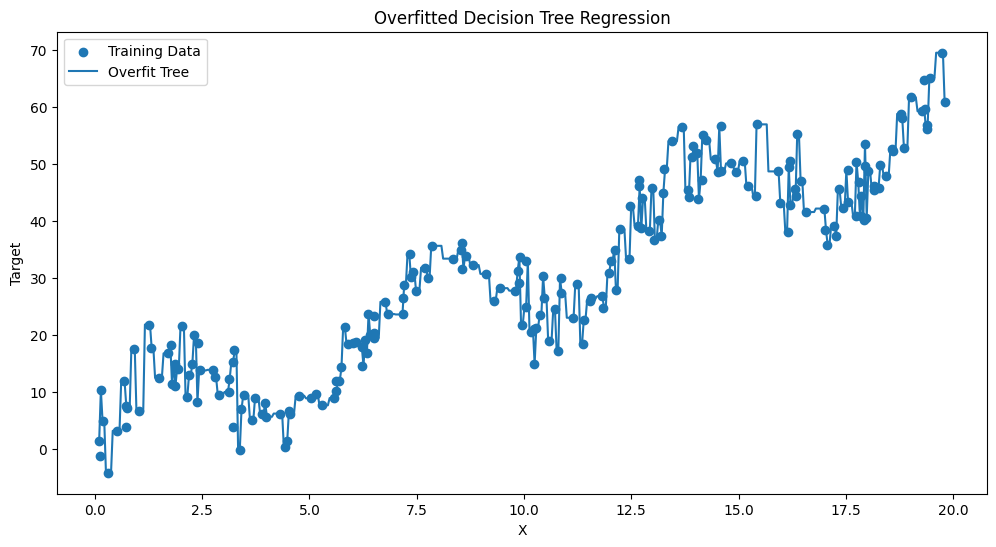

In [8]:
# Create a smooth range for visualization
X_plot = np.linspace(
    X["X"].min(),
    X["X"].max(),
    500
).reshape(-1, 1)

# Predictions from the overfit tree
y_plot = dt.predict(X_plot)

plt.figure(figsize=(12, 6))

plt.scatter(
    X_train,
    y_train,
    label="Training Data"
)

plt.plot(
    X_plot,
    y_plot,
    label="Overfit Tree"
)

plt.xlabel("X")
plt.ylabel("Target")
plt.title("Overfitted Decision Tree Regression")

plt.legend()
plt.show()

# Part B — Pre-Pruning

## 7. What is Pre-Pruning?

Pre-pruning controls the growth of the tree while it is being built.

Important parameters include:

- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_leaf_nodes`
- `min_impurity_decrease`

Here we use `max_depth=5` and `min_samples_leaf=5` as an example.

In [9]:
# Create a pre-pruned tree
dt_pruned = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

# Train
dt_pruned.fit(X_train, y_train)

print("Tree depth:", dt_pruned.get_depth())
print("Number of leaves:", dt_pruned.get_n_leaves())

Tree depth: 5
Number of leaves: 17


## 8. Evaluate the Pre-Pruned Tree

The goal is not necessarily to maximize training performance.

Instead, we want a better balance between training and testing performance.

In [10]:
# Predictions
y_train_pred_pruned = dt_pruned.predict(X_train)
y_test_pred_pruned = dt_pruned.predict(X_test)

# R²
train_r2_pruned = r2_score(y_train, y_train_pred_pruned)
test_r2_pruned = r2_score(y_test, y_test_pred_pruned)

# RMSE
train_rmse_pruned = np.sqrt(
    mean_squared_error(y_train, y_train_pred_pruned)
)

test_rmse_pruned = np.sqrt(
    mean_squared_error(y_test, y_test_pred_pruned)
)

print("Pre-Pruned Decision Tree")
print("-" * 30)
print("Training R² :", train_r2_pruned)
print("Testing R²  :", test_r2_pruned)
print("Training RMSE:", train_rmse_pruned)
print("Testing RMSE :", test_rmse_pruned)

Pre-Pruned Decision Tree
------------------------------
Training R² : 0.9471373974735604
Testing R²  : 0.9405402670130423
Training RMSE: 3.9208406637848894
Testing RMSE : 4.507740572619356


## 9. Compare Overfit and Pre-Pruned Models

This comparison makes the effect of pruning easier to understand.

Usually, pruning:

- increases training error slightly
- reduces unnecessary complexity
- can improve testing performance
- reduces the train/test performance gap

In [11]:
comparison = pd.DataFrame({
    "Model": [
        "Overfit Tree",
        "Pre-Pruned Tree"
    ],
    "Train R2": [
        train_r2,
        train_r2_pruned
    ],
    "Test R2": [
        test_r2,
        test_r2_pruned
    ],
    "Train RMSE": [
        train_rmse,
        train_rmse_pruned
    ],
    "Test RMSE": [
        test_rmse,
        test_rmse_pruned
    ],
    "Tree Depth": [
        dt.get_depth(),
        dt_pruned.get_depth()
    ],
    "Leaves": [
        dt.get_n_leaves(),
        dt_pruned.get_n_leaves()
    ]
})

display(comparison)

,Model,Train R2,Test R2,Train RMSE,Test RMSE,Tree Depth,Leaves
0,Overfit Tree,1.000000,0.920035,0.000000,5.227525,17,210
1,Pre-Pruned Tree,0.947137,0.940540,3.920841,4.507741,5,17


## 10. Visual Comparison

The unrestricted tree is usually much more complex, while the pre-pruned tree is smoother and simpler.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


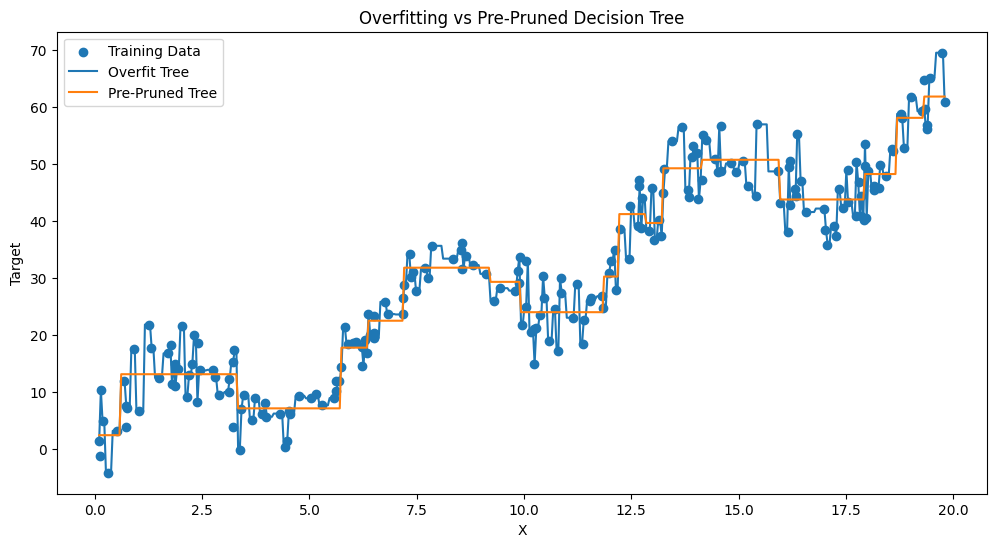

In [12]:
y_overfit = dt.predict(X_plot)
y_pruned = dt_pruned.predict(X_plot)

plt.figure(figsize=(12, 6))

plt.scatter(
    X_train,
    y_train,
    label="Training Data"
)

plt.plot(
    X_plot,
    y_overfit,
    label="Overfit Tree"
)

plt.plot(
    X_plot,
    y_pruned,
    label="Pre-Pruned Tree"
)

plt.xlabel("X")
plt.ylabel("Target")
plt.title("Overfitting vs Pre-Pruned Decision Tree")

plt.legend()
plt.show()

# Part C — Important Pre-Pruning Hyperparameters

## 11. `max_depth`

Controls the maximum depth of the tree.

- Very small → possible underfitting
- Appropriate → good generalization
- Very large → possible overfitting

Example:

```python
DecisionTreeRegressor(max_depth=5)
```

In [13]:
for depth in [2, 3, 5, 8, None]:
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train, y_train)

    train_rmse_value = np.sqrt(
        mean_squared_error(
            y_train,
            model.predict(X_train)
        )
    )

    test_rmse_value = np.sqrt(
        mean_squared_error(
            y_test,
            model.predict(X_test)
        )
    )

    print(
        f"max_depth={str(depth):<4} | "
        f"Train RMSE={train_rmse_value:.3f} | "
        f"Test RMSE={test_rmse_value:.3f}"
    )


max_depth=2    | Train RMSE=5.506 | Test RMSE=5.609
max_depth=3    | Train RMSE=4.942 | Test RMSE=5.372
max_depth=5    | Train RMSE=3.669 | Test RMSE=4.722
max_depth=8    | Train RMSE=2.322 | Test RMSE=4.765
max_depth=None | Train RMSE=0.000 | Test RMSE=5.228


## 12. `min_samples_split`

Minimum number of samples required to split an internal node.

For example:

```python
DecisionTreeRegressor(min_samples_split=10)
```

A node containing fewer than 10 samples will not be split further.

In [14]:
# Example: min_samples_split

for value in [2, 5, 10, 20]:
    model = DecisionTreeRegressor(
        min_samples_split=value,
        random_state=42
    )
    model.fit(X_train, y_train)

    test_rmse_value = np.sqrt(
        mean_squared_error(
            y_test,
            model.predict(X_test)
        )
    )

    print(
        f"min_samples_split={value:<3} | "
        f"Test RMSE={test_rmse_value:.3f}"
    )

min_samples_split=2   | Test RMSE=5.228
min_samples_split=5   | Test RMSE=4.902
min_samples_split=10  | Test RMSE=4.531
min_samples_split=20  | Test RMSE=4.655


## 13. `min_samples_leaf`

Minimum number of samples allowed in a leaf.

This is particularly useful for preventing a regression tree from making predictions based on extremely small groups.

Example:

```python
DecisionTreeRegressor(min_samples_leaf=5)
```

In [15]:
# Example: min_samples_leaf

for value in [1, 2, 5, 10]:
    model = DecisionTreeRegressor(
        min_samples_leaf=value,
        random_state=42
    )
    model.fit(X_train, y_train)

    test_rmse_value = np.sqrt(
        mean_squared_error(
            y_test,
            model.predict(X_test)
        )
    )

    print(
        f"min_samples_leaf={value:<3} | "
        f"Test RMSE={test_rmse_value:.3f}"
    )

min_samples_leaf=1   | Test RMSE=5.228
min_samples_leaf=2   | Test RMSE=4.774
min_samples_leaf=5   | Test RMSE=4.499
min_samples_leaf=10  | Test RMSE=4.732


## 14. `max_leaf_nodes`

Controls the maximum number of terminal nodes.

Example:

```python
DecisionTreeRegressor(max_leaf_nodes=10)
```

Fewer leaves generally means a simpler model.

In [16]:
# Example: max_leaf_nodes

for value in [5, 10, 20, 30, None]:
    model = DecisionTreeRegressor(
        max_leaf_nodes=value,
        random_state=42
    )
    model.fit(X_train, y_train)

    test_rmse_value = np.sqrt(
        mean_squared_error(
            y_test,
            model.predict(X_test)
        )
    )

    print(
        f"max_leaf_nodes={str(value):<4} | "
        f"Test RMSE={test_rmse_value:.3f}"
    )

max_leaf_nodes=5    | Test RMSE=5.583
max_leaf_nodes=10   | Test RMSE=5.103
max_leaf_nodes=20   | Test RMSE=4.349
max_leaf_nodes=30   | Test RMSE=4.226
max_leaf_nodes=None | Test RMSE=5.228


## 15. `min_impurity_decrease`

A split is made only when it produces at least the specified impurity reduction.

For regression, this relates to reduction in squared error/variance.

Example:

```python
DecisionTreeRegressor(min_impurity_decrease=0.01)
```

In [17]:
# Example: min_impurity_decrease

for value in [0.0, 0.01, 0.1]:
    model = DecisionTreeRegressor(
        min_impurity_decrease=value,
        random_state=42
    )
    model.fit(X_train, y_train)

    print(
        f"min_impurity_decrease={value} | "
        f"Depth={model.get_depth()} | "
        f"Leaves={model.get_n_leaves()}"
    )

min_impurity_decrease=0.0 | Depth=17 | Leaves=210
min_impurity_decrease=0.01 | Depth=16 | Leaves=151
min_impurity_decrease=0.1 | Depth=9 | Leaves=54


# Part D — Post-Pruning

## 16. Cost-Complexity Pruning

Post-pruning allows the tree to grow and then removes branches that do not justify their complexity.

Scikit-learn provides this through:

```python
ccp_alpha
```

The cost-complexity objective can be expressed as:

\[
R_\alpha(T) = R(T) + \alpha |T|
\]

where:

- `R(T)` = tree error
- `|T|` = number of leaves
- `alpha` = complexity penalty

Higher `ccp_alpha` generally results in more pruning.

In [18]:
# Create a fully grown tree for post-pruning
tree = DecisionTreeRegressor(
    random_state=42
)

tree.fit(X_train, y_train)

print("Initial depth:", tree.get_depth())
print("Initial leaves:", tree.get_n_leaves())

Initial depth: 17
Initial leaves: 210


## 17. Obtain Candidate `ccp_alpha` Values

`cost_complexity_pruning_path()` returns effective alpha values that can be used to investigate pruning.

In [19]:
path = tree.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = path.ccp_alphas

print("Number of candidate alpha values:", len(ccp_alphas))
print("First few values:", ccp_alphas[:10])

Number of candidate alpha values: 160
First few values: [0.00000000e+00 1.55656072e-05 2.41319540e-05 4.38251519e-05
 8.86702032e-05 2.05040448e-04 3.08096460e-04 3.25295383e-04
 3.92917122e-04 4.47597540e-04]


## 18. Train Trees with Different `ccp_alpha` Values

We train one tree for every candidate alpha value.

In [20]:
trees = []

for alpha in ccp_alphas:
    model = DecisionTreeRegressor(
        ccp_alpha=alpha,
        random_state=42
    )

    model.fit(X_train, y_train)
    trees.append(model)

print("Number of trees trained:", len(trees))

Number of trees trained: 160


## 19. Evaluate the Trees

We compare training and testing R² for different values of `ccp_alpha`.

In [21]:
train_scores = []
test_scores = []

for model in trees:
    train_scores.append(
        model.score(X_train, y_train)
    )

    test_scores.append(
        model.score(X_test, y_test)
    )

print("Evaluation completed.")

Evaluation completed.


## 20. Plot Training vs Testing R²

This plot helps us see how model complexity changes as `ccp_alpha` increases.

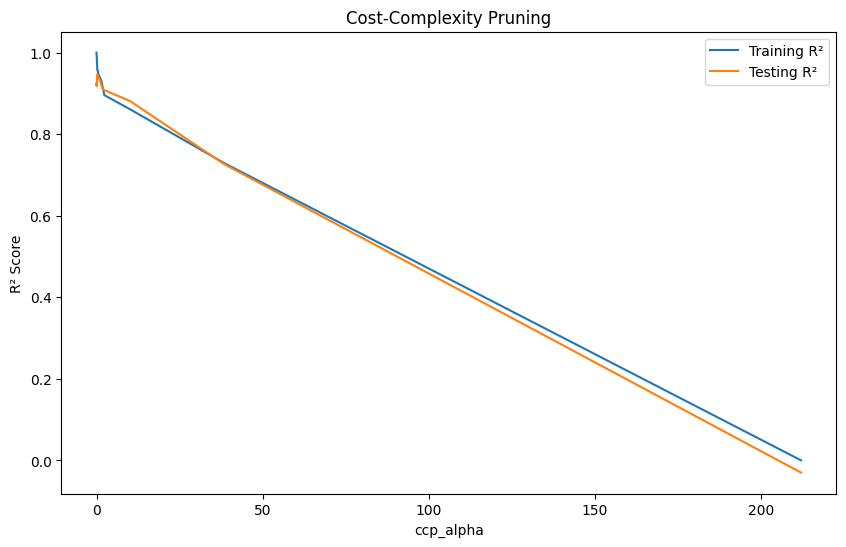

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    ccp_alphas,
    train_scores,
    label="Training R²"
)

plt.plot(
    ccp_alphas,
    test_scores,
    label="Testing R²"
)

plt.xlabel("ccp_alpha")
plt.ylabel("R² Score")
plt.title("Cost-Complexity Pruning")

plt.legend()
plt.show()

## 21. Select a Candidate `ccp_alpha`

For demonstration, we identify the alpha producing the highest test R².

### Important note

In a real ML project, the test set should not be used to select hyperparameters. A better approach is cross-validation on the training data, followed by one final evaluation on the untouched test set.

In [23]:
best_index = np.argmax(test_scores)
best_alpha_demo = ccp_alphas[best_index]

print("Best alpha in this demonstration:", best_alpha_demo)

Best alpha in this demonstration: 0.2407648275301229


## 22. Train the Post-Pruned Tree

Now create a final tree using the selected demonstration alpha.

In [24]:
post_pruned_tree = DecisionTreeRegressor(
    ccp_alpha=best_alpha_demo,
    random_state=42
)

post_pruned_tree.fit(X_train, y_train)

print("Post-pruned depth:", post_pruned_tree.get_depth())
print("Post-pruned leaves:", post_pruned_tree.get_n_leaves())

Post-pruned depth: 7
Post-pruned leaves: 21


In [25]:
# Evaluate post-pruned tree

post_train_pred = post_pruned_tree.predict(X_train)
post_test_pred = post_pruned_tree.predict(X_test)

post_train_r2 = r2_score(y_train, post_train_pred)
post_test_r2 = r2_score(y_test, post_test_pred)

post_train_rmse = np.sqrt(
    mean_squared_error(y_train, post_train_pred)
)

post_test_rmse = np.sqrt(
    mean_squared_error(y_test, post_test_pred)
)

print("Post-Pruned Tree")
print("-" * 30)
print("Training R² :", post_train_r2)
print("Testing R²  :", post_test_r2)
print("Training RMSE:", post_train_rmse)
print("Testing RMSE :", post_test_rmse)

Post-Pruned Tree
------------------------------
Training R² : 0.9579495075628451
Testing R²  : 0.9463454300109992
Training RMSE: 3.4969584040720405
Testing RMSE : 4.28204074838371


# Part E — Hyperparameter Tuning

## 23. GridSearchCV

Instead of manually selecting one or two parameters, we can search over several combinations.

We use 5-fold cross-validation on the training data.

The test set remains untouched until final evaluation.

In [26]:
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_leaf_nodes": [None, 5, 10, 20]
}

base_model = DecisionTreeRegressor(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-grid_search.best_score_)

Best Parameters:
{'max_depth': 5, 'max_leaf_nodes': None, 'min_samples_leaf': 2, 'min_samples_split': 5}

Best Cross-Validation RMSE:
4.73508026279853


## 24. Evaluate the Tuned Model on the Test Set

Now that hyperparameters were selected using cross-validation on the training data, we can evaluate the final model once on the test set.

In [28]:
best_model = grid_search.best_estimator_

best_train_pred = best_model.predict(X_train)
best_test_pred = best_model.predict(X_test)

best_train_r2 = r2_score(y_train, best_train_pred)
best_test_r2 = r2_score(y_test, best_test_pred)

best_train_rmse = np.sqrt(
    mean_squared_error(y_train, best_train_pred)
)

best_test_rmse = np.sqrt(
    mean_squared_error(y_test, best_test_pred)
)

print("Tuned Decision Tree")
print("-" * 30)
print("Training R² :", best_train_r2)
print("Testing R²  :", best_test_r2)
print("Training RMSE:", best_train_rmse)
print("Testing RMSE :", best_test_rmse)

print("\nTree depth:", best_model.get_depth())
print("Number of leaves:", best_model.get_n_leaves())

Tuned Decision Tree
------------------------------
Training R² : 0.9518954636944943
Testing R²  : 0.9421313275100803
Training RMSE: 3.7402268175372635
Testing RMSE : 4.447021164254302

Tree depth: 5
Number of leaves: 25


# Part F — Final Model Comparison

## 25. Compare All Approaches

We compare:

1. Fully grown / overfit tree
2. Pre-pruned tree
3. Post-pruned tree
4. Hyperparameter-tuned tree

In [29]:
final_comparison = pd.DataFrame({
    "Model": [
        "Overfit Tree",
        "Pre-Pruned Tree",
        "Post-Pruned Tree",
        "Tuned Tree"
    ],
    "Train R2": [
        train_r2,
        train_r2_pruned,
        post_train_r2,
        best_train_r2
    ],
    "Test R2": [
        test_r2,
        test_r2_pruned,
        post_test_r2,
        best_test_r2
    ],
    "Train RMSE": [
        train_rmse,
        train_rmse_pruned,
        post_train_rmse,
        best_train_rmse
    ],
    "Test RMSE": [
        test_rmse,
        test_rmse_pruned,
        post_test_rmse,
        best_test_rmse
    ]
})

display(final_comparison)

,Model,Train R2,Test R2,Train RMSE,Test RMSE
0,Overfit Tree,1.000000,0.920035,0.000000,5.227525
1,Pre-Pruned Tree,0.947137,0.940540,3.920841,4.507741
2,Post-Pruned Tree,0.957950,0.946345,3.496958,4.282041
3,Tuned Tree,0.951895,0.942131,3.740227,4.447021


## 26. Final Visualization

This visualization compares the unrestricted tree with the tuned tree.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


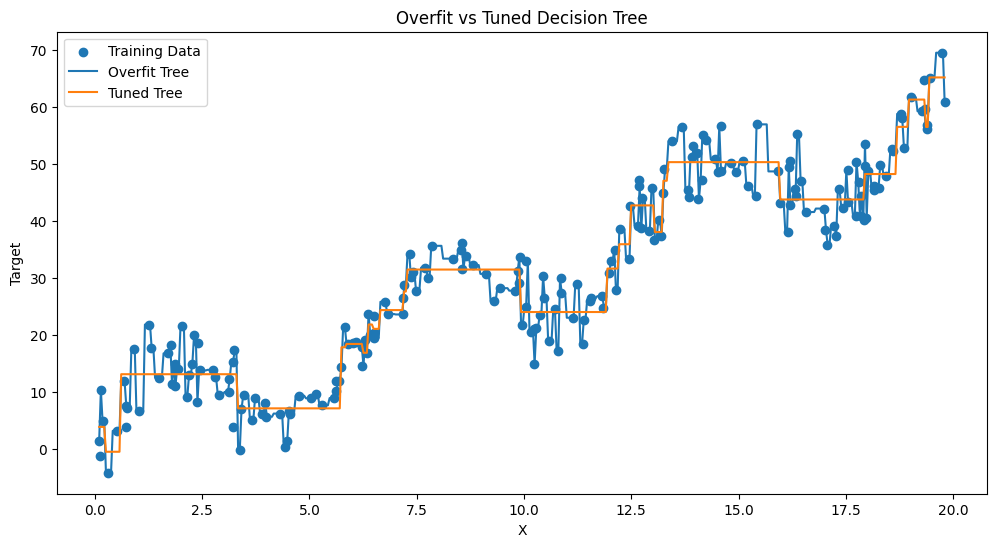

In [30]:
y_overfit_final = dt.predict(X_plot)
y_tuned_final = best_model.predict(X_plot)

plt.figure(figsize=(12, 6))

plt.scatter(
    X_train,
    y_train,
    label="Training Data"
)

plt.plot(
    X_plot,
    y_overfit_final,
    label="Overfit Tree"
)

plt.plot(
    X_plot,
    y_tuned_final,
    label="Tuned Tree"
)

plt.xlabel("X")
plt.ylabel("Target")
plt.title("Overfit vs Tuned Decision Tree")

plt.legend()
plt.show()

# Key Takeaways

## Overfitting

A Decision Tree can become too complex and memorize training data.

**Symptoms:**

- Very high training R²
- Much lower testing R²
- Very low training RMSE
- Higher testing RMSE
- Very deep tree / many leaves

## Pre-Pruning

Control tree growth using:

- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_leaf_nodes`
- `min_impurity_decrease`

## Post-Pruning

Grow the tree and then remove unnecessary branches using:

- `ccp_alpha`
- Cost-complexity pruning

## Hyperparameter Tuning

Use cross-validation, such as `GridSearchCV`, to find a good combination of hyperparameters.

### Golden Rule

> Do not choose the model because it performs best on training data. Choose a model that generalizes well to unseen data.

### Recommended Decision Tree Workflow

```text
Data
 ↓
Train/Test Split
 ↓
Build Baseline Tree
 ↓
Check Train vs Test Performance
 ↓
Detect Overfitting
 ↓
Pre-Pruning / Post-Pruning
 ↓
Hyperparameter Tuning with Cross-Validation
 ↓
Final Evaluation on Test Set
```